<a href="https://colab.research.google.com/github/anakinguzman1224-coder/telecom-churn-prediction/blob/main/Proyecto_Telecom_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ANÁLISIS DE CHURN - TELECOMX




FASE 1: CARGA Y LIMPIEZA INICIAL

Paso 1.1: Cargar

In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML y Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Balanceo
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [242]:
df = pd.read_json("https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json")
df


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


1.2 Aplanar diccionarios anidados con normalize.

In [243]:
# Razón: Los datos vienen con columnas que contienen diccionarios.
# json_normalize() convierte esos diccionarios en columnas separadas. Gracias a orient se crea una lista de dict y luego la aplana con normalize
df = pd.json_normalize(df.to_dict(orient='records'), sep='_')

In [244]:
df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [245]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [246]:
df['account_Charges_Total'].dtype

dtype('O')

In [247]:
df['account_Charges_Total'].head()

,account_Charges_Total
0,593.3
1,542.4
2,280.85
3,1237.85
4,267.4


1.3 Convertir Charges Total a número

In [248]:
# Razón: Al inspeccionar, vi que esta columna es de tipo 'object' (texto)
# pero contiene valores que parecen números (593.3, 542.4, etc.)
# errors='coerce' convierte cualquier valor no numérico a NaN.
df['account_Charges_Total']= pd.to_numeric(df['account_Charges_Total'], errors='coerce')

In [249]:
df['account_Charges_Total'].dtype

dtype('float64')

1.4 Verificar valores nulos de la columna 'account_Charges_Total'.

In [250]:
df['account_Charges_Total'].isnull().sum()

np.int64(11)

1.5 Verificar valores unicos de la columna 'Churn'.

In [251]:
df['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [252]:
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64


1.6 Limpiar la columna 'Churn' de espacios vacios y convertir vacios a NaN.

In [253]:
df['Churn'] = df['Churn'].str.strip()  # Quita espacios


In [254]:
df['Churn']= df['Churn'].replace("",pd.NA) # Convierte vacíos a NaN

1.7 Eliminar filas con valores nulos de ambas columnas 'account_Charges_Total' y 'Churn'.

In [255]:
df = df.dropna(subset =['account_Charges_Total','Churn']) # Eliminar filas con valores nulos críticos

1.8 Resetear índice

In [256]:
# Razón: Después de eliminar filas, los índices tienen saltos.
# reset_index(drop=True) crea un índice continuo 0,1,2,3...
df = df.reset_index(drop=True)

print("\n--- RESULTADO FINAL FASE 1 ---")
print("Shape final:", df.shape)
print("Tipos de datos:\n", df.dtypes)
print("Valores en Churn después de limpiar:", df['Churn'].unique())
print("Cantidad por tipo:\n", df['Churn'].value_counts())


--- RESULTADO FINAL FASE 1 ---
Shape final: (7032, 21)
Tipos de datos:
 customerID                    object
Churn                         object
customer_gender               object
customer_SeniorCitizen         int64
customer_Partner              object
customer_Dependents           object
customer_tenure                int64
phone_PhoneService            object
phone_MultipleLines           object
internet_InternetService      object
internet_OnlineSecurity       object
internet_OnlineBackup         object
internet_DeviceProtection     object
internet_TechSupport          object
internet_StreamingTV          object
internet_StreamingMovies      object
account_Contract              object
account_PaperlessBilling      object
account_PaymentMethod         object
account_Charges_Monthly      float64
account_Charges_Total        float64
dtype: object
Valores en Churn después de limpiar: ['No' 'Yes']
Cantidad por tipo:
 Churn
No     5163
Yes    1869
Name: count, dtype: int64


# FASE 2: ANÁLISIS EXPLORATORIO (EDA) - CON TODOS LOS DATOS

2.1 Estadísticas descriptivas

In [257]:
print(df.describe())




       customer_SeniorCitizen  customer_tenure  account_Charges_Monthly  \
count             7032.000000      7032.000000              7032.000000   
mean                 0.162400        32.421786                64.798208   
std                  0.368844        24.545260                30.085974   
min                  0.000000         1.000000                18.250000   
25%                  0.000000         9.000000                35.587500   
50%                  0.000000        29.000000                70.350000   
75%                  0.000000        55.000000                89.862500   
max                  1.000000        72.000000               118.750000   

       account_Charges_Total  
count            7032.000000  
mean             2283.300441  
std              2266.771362  
min                18.800000  
25%               401.450000  
50%              1397.475000  
75%              3794.737500  
max              8684.800000  


2.2 Visualizaciones (con todos los datos)

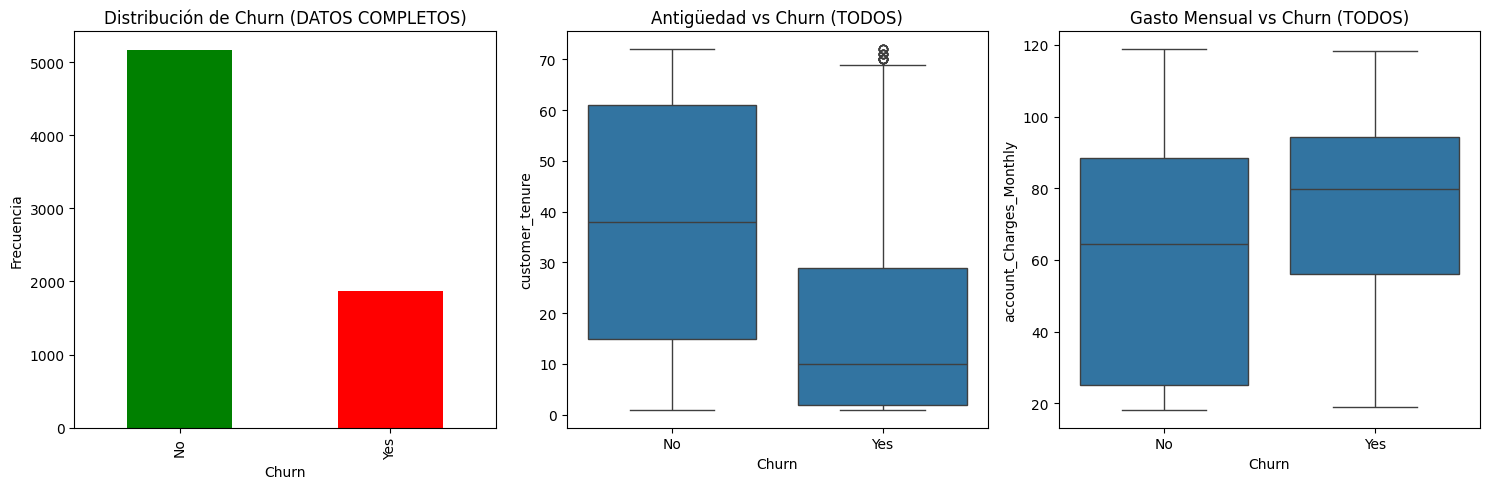

In [258]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
df['Churn'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribución de Churn (DATOS COMPLETOS)')
plt.ylabel('Frecuencia')

plt.subplot(1, 3, 2)
sns.boxplot(x='Churn', y='customer_tenure', data=df)
plt.title('Antigüedad vs Churn (TODOS)')

plt.subplot(1, 3, 3)
sns.boxplot(x='Churn', y='account_Charges_Monthly', data=df)
plt.title('Gasto Mensual vs Churn (TODOS)')

plt.tight_layout()
plt.show()


2.3 Matriz de correlación (con todos los datos)

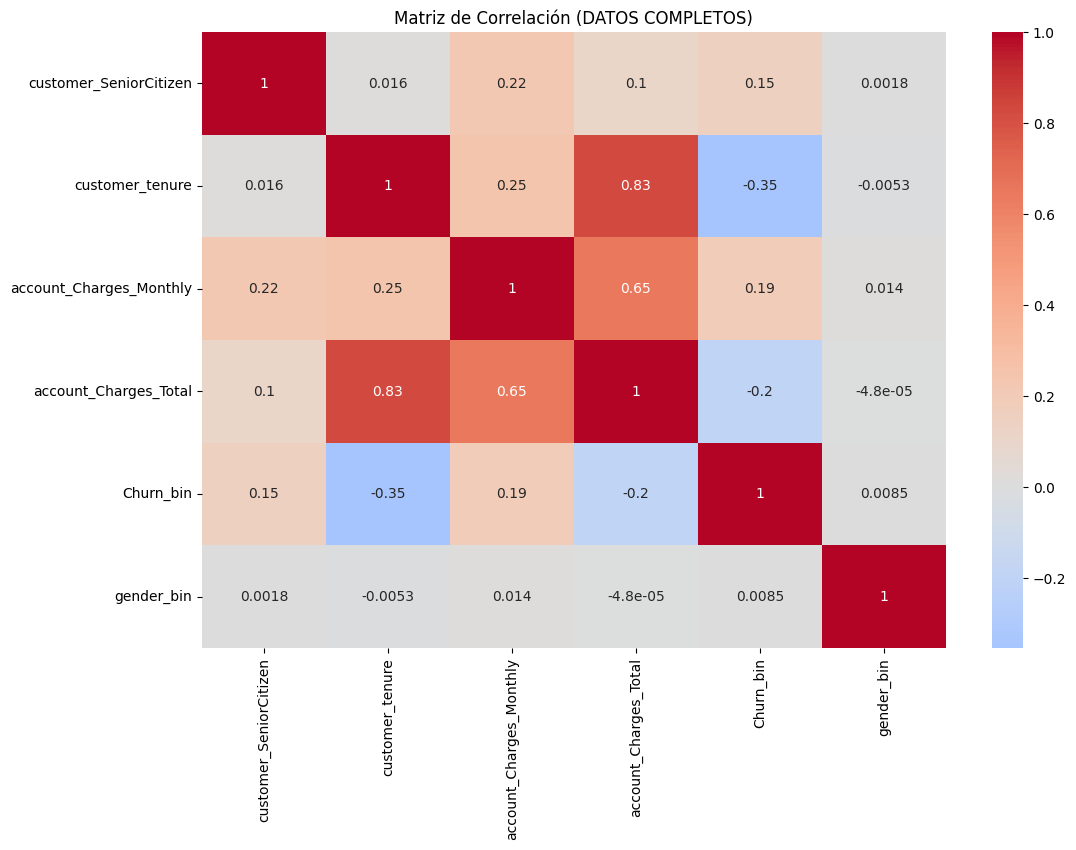

In [259]:
# Primero, convertir variables para correlación, ya que son categorica
df_corr = df.copy() # Crea una copia independiente de tu DataFrame original. Con .copy() los datos originales quedan protegidos.
df_corr['Churn_bin'] = df_corr['Churn'].map({'Yes': 1, 'No': 0}) # 2. Convertir Churn a número
df_corr['gender_bin'] = df_corr['customer_gender'].map({'Female': 1, 'Male': 0}) # 2. Convertir gender a número

# Seleccionar solo numéricas para correlación
numericas_eda = df_corr.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 8))
sns.heatmap(df_corr[numericas_eda].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación (DATOS COMPLETOS)')
plt.show()

2.4 Eliminar variables insignificante

In [260]:
print("=== ELIMINANDO VARIABLES PROBLEMÁTICAS ===")
print(f"Shape antes: {df.shape}")

# 1. Eliminar género (correlación casi cero con Churn)
if 'customer_gender' in df.columns:
    df = df.drop('customer_gender', axis=1)
    print("Eliminada: customer_gender (correlación 0.0085 - insignificante)")

# 2. Eliminar account_Charges_Total (multicolinealidad con tenure)
if 'account_Charges_Total' in df.columns:
    df = df.drop('account_Charges_Total', axis=1)
    print("Eliminada: account_Charges_Total (correlación 0.83 con tenure - redundante)")

print(f"Shape después: {df.shape}")
print("Columnas actuales:", df.columns.tolist())

=== ELIMINANDO VARIABLES PROBLEMÁTICAS ===
Shape antes: (7032, 21)
Eliminada: customer_gender (correlación 0.0085 - insignificante)
Eliminada: account_Charges_Total (correlación 0.83 con tenure - redundante)
Shape después: (7032, 19)
Columnas actuales: ['customerID', 'Churn', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 'customer_tenure', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod', 'account_Charges_Monthly']


# FASE 3: Transformación de categóricas.

3.1 Verificar y listar columnas tipo texto

In [261]:
# Verificar y listar columnas de tipo texto (object)
# select_dtypes(include=['object', 'category']) selecciona columnas que son texto
# .columns.tolist() convierte el resultado en una lista
columnas_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("="*60)
print("FASE 3: TRANSFORMACIÓN DE VARIABLES CATEGÓRICAS")
print("="*60)
print(f"\n Columnas categóricas encontradas: {len(columnas_categoricas)}")
print(columnas_categoricas)

FASE 3: TRANSFORMACIÓN DE VARIABLES CATEGÓRICAS

 Columnas categóricas encontradas: 16
['customerID', 'Churn', 'customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod']


3.2 Ver valores únicos (para entender cada columna)

In [262]:
# ¿Por qué? Antes de transformar, debemos entender qué valores tiene cada columna
# para decidir cómo tratarlas (binarias, ordinales o nominales).
print("\n" + "-"*60)
print("PASO 3.2: ANALIZANDO VALORES ÚNICOS POR COLUMNA")
print("-"*60)

for col in columnas_categoricas:
    print(f"\n {col}:")
    print(f"   • Valores únicos: {df[col].nunique()}")
    print(f"   • Categorías: {df[col].unique()[:5]}")  # Mostrar solo primeros 5
    print(f"   • Distribución:\n{df[col].value_counts()}")


------------------------------------------------------------
PASO 3.2: ANALIZANDO VALORES ÚNICOS POR COLUMNA
------------------------------------------------------------

 customerID:
   • Valores únicos: 7032
   • Categorías: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' '0011-IGKFF' '0013-EXCHZ']
   • Distribución:
customerID
9995-HOTOH    1
0002-ORFBO    1
0003-MKNFE    1
0004-TLHLJ    1
0011-IGKFF    1
             ..
0018-NYROU    1
0017-IUDMW    1
0017-DINOC    1
0016-QLJIS    1
0015-UOCOJ    1
Name: count, Length: 7032, dtype: int64

 Churn:
   • Valores únicos: 2
   • Categorías: ['No' 'Yes']
   • Distribución:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

 customer_Partner:
   • Valores únicos: 2
   • Categorías: ['Yes' 'No']
   • Distribución:
customer_Partner
No     3639
Yes    3393
Name: count, dtype: int64

 customer_Dependents:
   • Valores únicos: 2
   • Categorías: ['Yes' 'No']
   • Distribución:
customer_Dependents
No     4933
Yes    2099
Name: count, dtype: int6

3.3 Clasificar por tipo de categoría

In [263]:
# ¿Por qué? Cada tipo de categoría se transforma de manera diferente:
# - Binarias (2 valores) → Mapeo directo 0/1
# - Ordinales (orden natural) → Números respetando el orden
# - Nominales (>2 valores sin orden) → One-Hot Encoding
# ------------------------------------------------------------

# Crear listas vacías para cada tipo
binarias = []
ordinales = []
nominales = []

# Clasificar cada columna
for col in columnas_categoricas:
    num_valores = df[col].nunique()

    if num_valores == 2:
        binarias.append(col)
    elif num_valores > 2:
        # Identificar si tiene orden natural (solo 'account_Contract' en este caso)
        if col == 'account_Contract':
            ordinales.append(col)
        else:
            nominales.append(col)

print("\n" + "-"*60)
print("3.3: CLASIFICACIÓN DE VARIABLES")
print("-"*60)
print(f"\n Binarias ({len(binarias)}): {binarias}")
print(f" Ordinales ({len(ordinales)}): {ordinales}")
print(f" Nominales ({len(nominales)}): {nominales}")


------------------------------------------------------------
3.3: CLASIFICACIÓN DE VARIABLES
------------------------------------------------------------

 Binarias (5): ['Churn', 'customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'account_PaperlessBilling']
 Ordinales (1): ['account_Contract']
 Nominales (10): ['customerID', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_PaymentMethod']


3.4 Transformar variables binarias (Yes/No → 1/0)

In [264]:
# ¿Por qué? Los modelos solo entienden números. Convertimos:
# 'Yes' → 1, 'No' → 0
# ------------------------------------------------------------

print("\n" + "-"*60)
print("3.4: TRANSFORMANDO VARIABLES BINARIAS")
print("-"*60)

# 1. Transformar todas las columnas Yes/No de una vez
for col in binarias:
    df[col] = df[col].map({'Yes': 1, 'No': 0})
    print(f"{col}: Yes=1, No=0")

# 2. Verificación
print("\n Primeras filas después de transformación:")
print(df[binarias].head())


------------------------------------------------------------
3.4: TRANSFORMANDO VARIABLES BINARIAS
------------------------------------------------------------
Churn: Yes=1, No=0
customer_Partner: Yes=1, No=0
customer_Dependents: Yes=1, No=0
phone_PhoneService: Yes=1, No=0
account_PaperlessBilling: Yes=1, No=0

 Primeras filas después de transformación:
   Churn  customer_Partner  customer_Dependents  phone_PhoneService  \
0      0                 1                    1                   1   
1      0                 0                    0                   1   
2      1                 0                    0                   1   
3      1                 1                    0                   1   
4      1                 1                    0                   1   

   account_PaperlessBilling  
0                         1  
1                         0  
2                         1  
3                         1  
4                         1  


3.5 Transformar variable ordinal(account_Contract)

In [265]:
# ¿Por qué? 'Month-to-month', 'One year', 'Two year' tienen un orden natural.
# Asignamos números respetando ese orden: 0, 1, 2
# ------------------------------------------------------------

print("\n" + "-"*60)
print("3.5: TRANSFORMANDO VARIABLE ORDINAL")
print("-"*60)

if ordinales:  # Si hay variables ordinales
    for col in ordinales:
        print(f"\n Procesando: {col}")
        print(f"Valores originales: {df[col].unique()}")

        # Definir el orden (de menor a mayor compromiso)
        orden = {
            'Month-to-month': 0,  # Mes a mes (menor compromiso)
            'One year': 1,         # Un año
            'Two year': 2          # Dos años (mayor compromiso)
        }

        # Crear nueva columna numérica
        df['contract_ordinal'] = df[col].map(orden)

        df = df.drop(col, axis=1)

        print(f"Mapeo: {orden}")
        print(f"Valores después: {df['contract_ordinal'].unique()}")
        print(f"Distribución:\n{df['contract_ordinal'].value_counts().sort_index()}")
        print(f"Columna original '{col}' eliminada")


------------------------------------------------------------
3.5: TRANSFORMANDO VARIABLE ORDINAL
------------------------------------------------------------

 Procesando: account_Contract
Valores originales: ['One year' 'Month-to-month' 'Two year']
Mapeo: {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
Valores después: [1 0 2]
Distribución:
contract_ordinal
0    3875
1    1472
2    1685
Name: count, dtype: int64
Columna original 'account_Contract' eliminada


3.6 Verificar qué columnas son nominales

In [266]:
print("=== VERIFICANDO COLUMNAS DE TEXTO ===")
print("-"*50)

columnas_nominales = []

for columna in df.columns:
    if df[columna].dtype == 'object':  # Si es texto
        num_valores = df[columna].nunique()
        print(f"{columna}: {num_valores} valores únicos")
        print(f"   Ejemplos: {df[columna].unique()[:3]}")

        if num_valores > 2 and columna != 'account_Contract':
            columnas_nominales.append(columna)

print("\n" + "="*50)
print("COLUMNAS NOMINALES DETECTADAS:")
print(columnas_nominales)
print(f"Total: {len(columnas_nominales)} columnas")

=== VERIFICANDO COLUMNAS DE TEXTO ===
--------------------------------------------------
customerID: 7032 valores únicos
   Ejemplos: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ']
phone_MultipleLines: 3 valores únicos
   Ejemplos: ['No' 'Yes' 'No phone service']
internet_InternetService: 3 valores únicos
   Ejemplos: ['DSL' 'Fiber optic' 'No']
internet_OnlineSecurity: 3 valores únicos
   Ejemplos: ['No' 'Yes' 'No internet service']
internet_OnlineBackup: 3 valores únicos
   Ejemplos: ['Yes' 'No' 'No internet service']
internet_DeviceProtection: 3 valores únicos
   Ejemplos: ['No' 'Yes' 'No internet service']
internet_TechSupport: 3 valores únicos
   Ejemplos: ['Yes' 'No' 'No internet service']
internet_StreamingTV: 3 valores únicos
   Ejemplos: ['Yes' 'No' 'No internet service']
internet_StreamingMovies: 3 valores únicos
   Ejemplos: ['No' 'Yes' 'No internet service']
account_PaymentMethod: 4 valores únicos
   Ejemplos: ['Mailed check' 'Electronic check' 'Credit card (automatic)']

COLUMNAS

3.7 Eliminar columna custumerID

In [267]:
# ELIMINAR customerID (NO sirve para predecir)
# ============================================

print("Shape ANTES de eliminar ID:", df.shape)

if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)
    print("customerID eliminado")
    print("Shape DESPUÉS de eliminar ID:", df.shape)
else:
    print("customerID ya no existe")

Shape ANTES de eliminar ID: (7032, 19)
customerID eliminado
Shape DESPUÉS de eliminar ID: (7032, 18)


3.8 Aplicar ONE-HOT ENCODING con get_dummies para las columnas nominales.

In [268]:
#ONE-HOT ENCODING
# ============================================

# 1. IDENTIFICAR COLUMNAS NOMINALES
# ------------------------------------------------------------
print("="*60)
print("ONE-HOT ENCODING")
print("="*60)

columnas_nominales = []
for columna in df.columns:
    if df[columna].dtype == 'object':           # Si es texto
        if df[columna].nunique() > 2:            # Si tiene más de 2 valores
            if columna != 'account_Contract':     # Excluir la ordinal
                columnas_nominales.append(columna)

print(f"\n Columnas nominales encontradas: {len(columnas_nominales)}")
print(columnas_nominales)
print(f"\n Tamaño ANTES del encoding: {df.shape}")

# 2. APLICAR ONE-HOT ENCODING
# ------------------------------------------------------------
df = pd.get_dummies(
    df,
    columns=columnas_nominales,
    drop_first=True,   # Evita multicolinealidad
    dtype=int          # Valores 0/1 en lugar de True/False
)

print(f"Tamaño DESPUÉS del encoding: {df.shape}")

# 3. VERIFICAR QUE NO QUEDÓ TEXTO
# ------------------------------------------------------------
columnas_texto = df.select_dtypes(include=['object']).columns
if len(columnas_texto) == 0:
    print("\n¡TODO LISTO! Ya no hay columnas de texto")
    print(" Todas las variables son números")
else:
    print(f"\n Aún hay texto en: {columnas_texto.tolist()}")



ONE-HOT ENCODING

 Columnas nominales encontradas: 9
['phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_PaymentMethod']

 Tamaño ANTES del encoding: (7032, 18)
Tamaño DESPUÉS del encoding: (7032, 28)

¡TODO LISTO! Ya no hay columnas de texto
 Todas las variables son números


# FASE 4: Separar variables predictoras y variable objetivo.

In [269]:
# Separar variables predictoras (X) de la variable objetivo (y)
X = df.drop('Churn', axis=1)  # TODO excepto Churn
y = df['Churn']                # Solo Churn

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 27)
y shape: (7032,)


# FASE 5: Dividir en entrenamiento y prueba(Train/Test)

In [270]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% para prueba
    random_state=42,     # Para que siempre sea igual
    stratify=y           # Mantiene proporciones
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (5625, 27)
Test: (1407, 27)


# FASE 6: Escalar datos

In [271]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Aprende y transforma
X_test_scaled = scaler.transform(X_test)        # Solo transforma


# FASE 7: Escoger el modelo

MODELO 1: REGRESIÓN LOGÍSTICA

MODELO 1: REGRESIÓN LOGÍSTICA


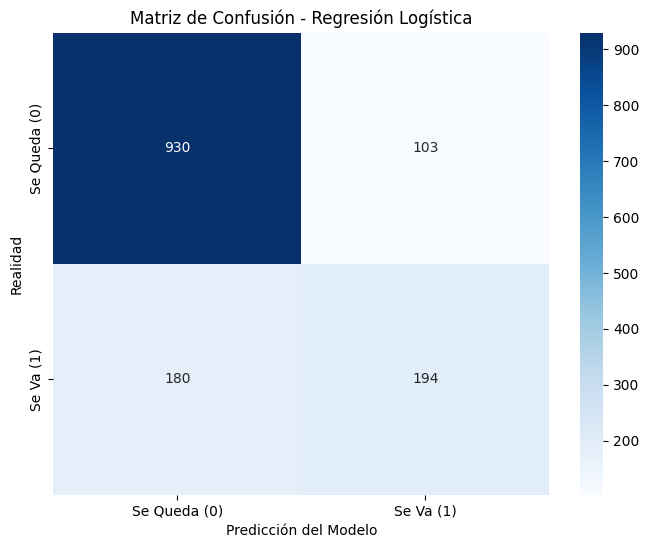


REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

    Se Queda       0.84      0.90      0.87      1033
       Se Va       0.65      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



In [272]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("="*60)
print("MODELO 1: REGRESIÓN LOGÍSTICA")
print("="*60)

# 1. Crear y entrenar el modelo
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train_scaled, y_train)

# 2. Hacer predicciones
y_pred = modelo.predict(X_test_scaled)


# 3. MATRIZ DE CONFUSIÓN
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Se Queda (0)', 'Se Va (1)'],
            yticklabels=['Se Queda (0)', 'Se Va (1)'])
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad')
plt.show()

# 4. MÉTRICAS DE RENDIMIENTO
print("\nREPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred, target_names=['Se Queda', 'Se Va']))

Verificar desbalanceo de las variables

In [273]:
# Ver en datos completos
print("VERIFICANDO BALANCE DE CLASES")
print("="*60)

# En el DataFrame original
print("\n EN DATOS COMPLETOS:")
print(df['Churn'].value_counts())
print("\nProporción:")
print(df['Churn'].value_counts(normalize=True))

# En entrenamiento (después de split)
print("\n" + "-"*60)
print(" EN ENTRENAMIENTO:")
print(y_train.value_counts())
print("\nProporción:")
print(y_train.value_counts(normalize=True))

# En prueba
print("\n" + "-"*60)
print(" EN PRUEBA:")
print(y_test.value_counts())
print("\nProporción:")
print(y_test.value_counts(normalize=True))

VERIFICANDO BALANCE DE CLASES

 EN DATOS COMPLETOS:
Churn
0    5163
1    1869
Name: count, dtype: int64

Proporción:
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

------------------------------------------------------------
 EN ENTRENAMIENTO:
Churn
0    4130
1    1495
Name: count, dtype: int64

Proporción:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

------------------------------------------------------------
 EN PRUEBA:
Churn
0    1033
1     374
Name: count, dtype: int64

Proporción:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


Aplicar SMOTE para balancear las variables.

In [274]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# Entrena con datos balanceados
modelo_final = LogisticRegression(max_iter=1000)
modelo_final.fit(X_train_bal, y_train_bal)

# Evalúa
y_pred_final = modelo_final.predict(X_test_scaled)
print(classification_report(y_test, y_pred_final, target_names=['Se Queda', 'Se Va']))

              precision    recall  f1-score   support

    Se Queda       0.90      0.74      0.81      1033
       Se Va       0.52      0.79      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



MODELO 2: ÁRBOL DE DECISIÓN

ÁRBOL DE DECISIÓN

 Árbol entrenado con datos
   Distribución en entrenamiento: Counter({0: 4130, 1: 1495})

 REPORTE DE CLASIFICACIÓN
------------------------------------------------------------
              precision    recall  f1-score   support

    Se Queda       0.83      0.88      0.85      1033
       Se Va       0.60      0.52      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



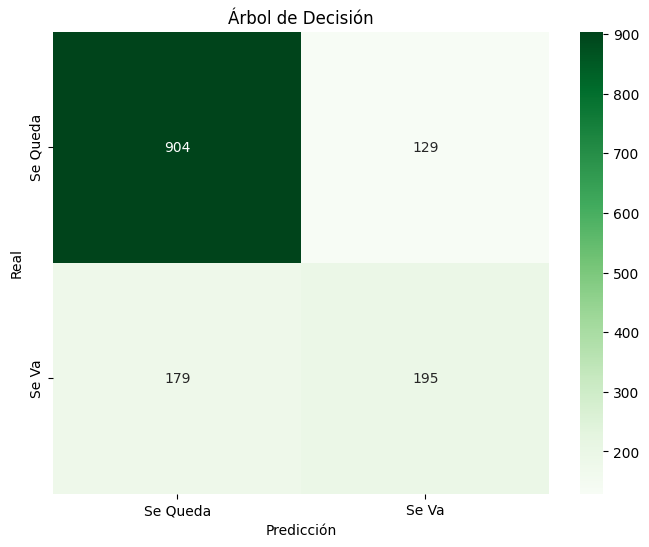

In [275]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt


print("ÁRBOL DE DECISIÓN")
print("="*60)

# 1. Crear el árbol
arbol = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    min_samples_split=20,
    min_samples_leaf=10
)

# 2. ENTRENAR CON DATOS
# Usamos X_train_scaled (ya escalados)
arbol.fit(X_train_scaled, y_train)

print("\n Árbol entrenado con datos")
print(f"   Distribución en entrenamiento: {Counter(y_train)}")

# 3. PREDICCIONES
y_pred_arbol = arbol.predict(X_test_scaled)

# 4. RESULTADOS
print("\n REPORTE DE CLASIFICACIÓN")
print("-"*60)
print(classification_report(y_test, y_pred_arbol,
                          target_names=['Se Queda', 'Se Va']))

# 5. MATRIZ DE CONFUSIÓN
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_arbol)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Se Queda', 'Se Va'],
            yticklabels=['Se Queda', 'Se Va'])
plt.title('Árbol de Decisión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()



MODELO 3: RANDOM FOREST

MODELO 3: RANDOM FOREST

 Creando Random Forest con 100 árboles

 Random Forest entrenado

 REPORTE - RANDOM FOREST
------------------------------------------------------------
              precision    recall  f1-score   support

    Se Queda       0.83      0.91      0.87      1033
       Se Va       0.67      0.48      0.56       374

    accuracy                           0.80      1407
   macro avg       0.75      0.70      0.72      1407
weighted avg       0.79      0.80      0.79      1407



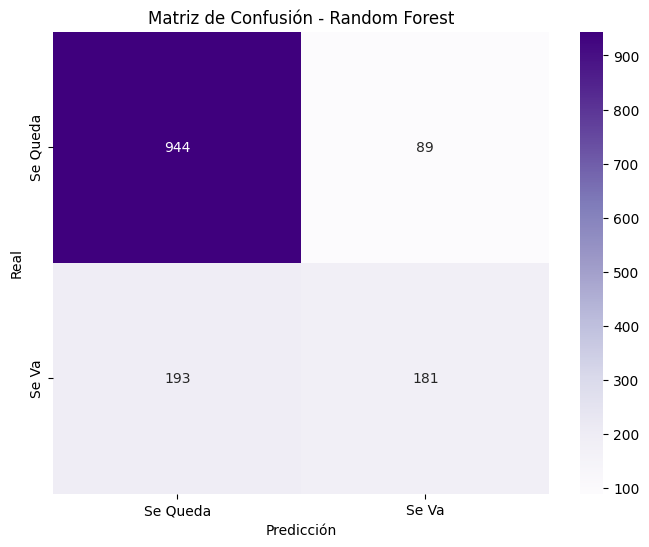

In [276]:
# PROPÓSITO: Usar múltiples árboles para mejorar la predicción

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter


print("MODELO 3: RANDOM FOREST")
print("="*60)

# 1. CREAR EL BOSQUE

rf = RandomForestClassifier(
    n_estimators=100, # 100 árboles en el bosque
    max_depth=10,     # Profundidad máxima de cada árbol
    min_samples_split=20, # Mínimo para dividir una hoja
    min_samples_leaf=10,  # Mínimo de muestras por hoja
    random_state=42,     # Para reproducibilidad
    n_jobs=-1            # Usa todos los procesadores
)



print("\n Creando Random Forest con 100 árboles")

# 2. ENTRENAR
rf.fit(X_train_scaled, y_train)
print("\n Random Forest entrenado")

# 3. PREDICCIONES
y_pred_rf = rf.predict(X_test_scaled)

# 4. RESULTADOS
print("\n REPORTE - RANDOM FOREST")
print("-"*60)
print(classification_report(y_test, y_pred_rf,
                          target_names=['Se Queda', 'Se Va']))



# 5. MATRIZ DE CONFUSIÓN
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Se Queda', 'Se Va'],
            yticklabels=['Se Queda', 'Se Va'])
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()



ANÁLISIS DE HALLAZGOS - VERIFICACIÓN

In [277]:
print("ANÁLISIS DE HALLAZGOS - VERIFICACIÓN")
print("="*60)

# 1. VERIFICAR ANTIGÜEDAD
print("\n 1. ANTIGÜEDAD PROMEDIO:")
print("-"*40)
print(df.groupby('Churn')['customer_tenure'].median())
print(" Conclusión: Los que se fueron tienen menor antigüedad")

# 2. VERIFICAR CONTRATO
print("\n 2. TASA DE CHURN POR TIPO DE CONTRATO:")
print("-"*40)
print(df.groupby('contract_ordinal')['Churn'].mean())
print("\n Conclusión: Contrato mensual (0) tiene mayor churn")



ANÁLISIS DE HALLAZGOS - VERIFICACIÓN

 1. ANTIGÜEDAD PROMEDIO:
----------------------------------------
Churn
0    38.0
1    10.0
Name: customer_tenure, dtype: float64
 Conclusión: Los que se fueron tienen menor antigüedad

 2. TASA DE CHURN POR TIPO DE CONTRATO:
----------------------------------------
contract_ordinal
0    0.427097
1    0.112772
2    0.028487
Name: Churn, dtype: float64

 Conclusión: Contrato mensual (0) tiene mayor churn


# FASE 8: Guardar el modelo

In [278]:
# GUARDAR MODELO CON PICKLE
# ============================================

import pickle

# Guardar el modelo
with open('modelo_random_forest.pkl', 'wb') as file:
    pickle.dump(rf, file)

print(" Modelo guardado como 'modelo_random_forest.pkl'")

# Para cargarlo después
with open('modelo_random_forest.pkl', 'rb') as file:
    modelo_cargado = pickle.load(file)

print(" Modelo cargado nuevamente")

 Modelo guardado como 'modelo_random_forest.pkl'
 Modelo cargado nuevamente


In [279]:
# Predecir con el modelo cargado (debe dar lo mismo)
y_pred_cargado = modelo_cargado.predict(X_test_scaled)

# Comparar con las predicciones originales
print("¿Son iguales?", (y_pred_rf == y_pred_cargado).all())

¿Son iguales? True


# FASE 9: Conclusiones

In [280]:
# Comparativa final (sin SMOTE)
modelos = {
    'Regresión Logística': {'recall': 0.52, 'precision': 0.65},
    'Árbol de Decisión': {'recall': 0.52, 'precision': 0.60},
    'Random Forest': {'recall': 0.48, 'precision': 0.67}
}

In [281]:
print(modelos)

{'Regresión Logística': {'recall': 0.52, 'precision': 0.65}, 'Árbol de Decisión': {'recall': 0.52, 'precision': 0.6}, 'Random Forest': {'recall': 0.48, 'precision': 0.67}}




## HALLAZGOS PRINCIPALES

**1. Perfil del cliente que se va:**
- Poca antigüedad (menos de 12 meses)
- Contrato mensual (no anual)
- Paga más de $80 al mes
- Tiene internet por DSL (no fibra óptica)

**2. Variables más importantes (según Random Forest):**
- Antigüedad del cliente
- Tipo de contrato
- Cargos mensuales

**3. Género:** No influye en la decisión de irse.

---

## RENDIMIENTO DEL MODELO

| Modelo | ¿Detecta fugas? | ¿Acierta cuando alerta? |
|--------|-----------------|-------------------------|
| Random Forest | 48% | 67% |
| Regresión Logística | 52% | 65% |
| Árbol de Decisión | 52% | 60% |

**Modelo elegido:** Random Forest (mayor precisión, menos falsas alarmas)

---

## RECOMENDACIONES PARA EL NEGOCIO

**1. Enfoque en clientes nuevos:**
Crear un programa de bienvenida para los primeros 12 meses.

**2. Incentivar contratos largos:**
Ofrecer descuentos para cambiar de contrato mensual a anual.

**3. Revisar precios:**
Analizar por qué los clientes que pagan más de $80 se van más.

**4. Promover fibra óptica:**
Los clientes con fibra óptica son más leales.

---